## Data Preprocessing

In [105]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {device}")

Device: cuda


In [106]:
with open("data/input.txt") as file:
    text = file.read()

text = text.lower()
chars = sorted(set(text))

print(f"Length of data: {len(text)}")
print(f"Vocabulary Size: {len(chars)}")

Length of data: 1115394
Vocabulary Size: 39


In [107]:
stoi = {char:i for i,char in enumerate(chars)}
itos = {i:char for i,char in enumerate(chars)}

def encode(text):
    return [stoi[i] for i in text]

def decode(ids):
    return "".join(itos[i] for i in ids)

data = torch.tensor(encode(text), dtype = torch.int64)
# data = data[:int(0.2 * data.shape[0])]   # using only 20% for quick test

In [108]:
split = int(0.9 * len(data))
train = data[:split]
test = data[split:]

print(f"No. of chars in train dataset: {len(train)}")
print(f"No. of chars in test dataset: {len(test)}\n")

block_size = 20

X_train = []
y_train = []

for i in range(len(train) - block_size):
    X_train.append(train[i:i + block_size])
    y_train.append(train[i+block_size])

X_train = torch.stack(X_train)
y_train = torch.stack(y_train)
print(f"No. of datapoints in train dataset: {len(X_train)}")
print(f"X_train shape : {X_train.shape}")
print(f"y_train shape: {y_train.shape}\n")

X_test = []
y_test = []

for i in range(len(test) - block_size):
    X_test.append(test[i:i + block_size])
    y_test.append(test[i + block_size])

X_test = torch.stack(X_test)
y_test = torch.stack(y_test)
print(f"No. of datapoints in test dataset: {len(X_test)}")
print(f"X_test shape : {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

No. of chars in train dataset: 1003854
No. of chars in test dataset: 111540

No. of datapoints in train dataset: 1003834
X_train shape : torch.Size([1003834, 20])
y_train shape: torch.Size([1003834])

No. of datapoints in test dataset: 111520
X_test shape : torch.Size([111520, 20])
y_test shape: torch.Size([111520])


## MLP

In [109]:
import torch
import torch.nn as nn

from torch.utils.data import TensorDataset, DataLoader


# Data Loader

batch_size = 64

train_dataset = TensorDataset(X_train, y_train)
test_dataset = TensorDataset(X_test, y_test)  

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

# Model

vocab_size = len(chars)
embedding_dim = 64
hidden_dim1 = 256
hidden_dim2 = 128

model = nn.Sequential(
    nn.Embedding(vocab_size, embedding_dim),
    nn.Flatten(),
    nn.Linear(block_size * embedding_dim, hidden_dim1),
    nn.ReLU(),
    nn.Linear(hidden_dim1, hidden_dim2),
    nn.Linear(hidden_dim2, vocab_size)
)

print(model)

Sequential(
  (0): Embedding(39, 64)
  (1): Flatten(start_dim=1, end_dim=-1)
  (2): Linear(in_features=1280, out_features=256, bias=True)
  (3): ReLU()
  (4): Linear(in_features=256, out_features=128, bias=True)
  (5): Linear(in_features=128, out_features=39, bias=True)
)


In [110]:
print(f"Total trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad)}")

Total trainable parameters: 368359


In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

train_loss_ = []
test_loss_ = []
epochs = 10

for epoch in range(epochs):

    # Training
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:

        # Forward
        logits = model(X_batch)

        # Loss
        loss = loss_fn(logits, y_batch)

        # Backpropagation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(train_loader)

    # Testing
    model.eval()
    test_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in test_loader:
            logits = model(X_batch)
            loss = loss_fn(logits, y_batch)

            test_loss += loss.item()

        test_loss /= len(test_loader)

    train_loss_.append(train_loss)
    test_loss_.append(test_loss)

    print(
        f"Epoch [{epoch+1}/{epochs}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Test Loss: {test_loss:.4f}"
    )

In [ ]:
def generate(model, text, max_new_chars):
    model.eval()

    for _ in range(max_new_chars):

        # Encode input
        context = torch.tensor(
            encode(text[-block_size:]),
            dtype=torch.long
        ).unsqueeze(0) # unsqueeze(0) - add a dim 1, model was trained to receive a batch of sequences, 
                      # so even when generating only one sequence, you need to represent it as a batch of size 1.

        with torch.no_grad():
            logits = model(context)

        probs = torch.softmax(logits, dim=-1)
        next_id = torch.multinomial(probs, num_samples=1).item()
        next_char = decode([next_id])

        text += next_char

    return text

In [ ]:
input = "the secene of evening with love"
output = generate(model, input, 300)

print(output)

the secene of evening with love fountimot-fort thief this is ming thinds cress; and injugly you. bardst to heip inst say onck you:
dir goess of do. : conds;
o' the preaced
amp!
may trivize:
to mirk to the raius
live ange in you.

thervans:
anay so mis ughalt comear
thou of thy fenangs to winatine ance you to him, who, and they, h


In [94]:
input = "the secene of evening with love"
output = generate(model, input, 300)

print(output)

the secene of evening with love, i'llso seoing to taft and all the plainot dry
i frathst you robe they it lood at onsuli cust'd prencess them to the gloann as you think, agher them.

menenius:
to't in him o' the me fout?

oufinius:
i well theck to hea, hond all to the: your deegns of ply raile unto to for't,
where to 'abt brokent


## Visualization

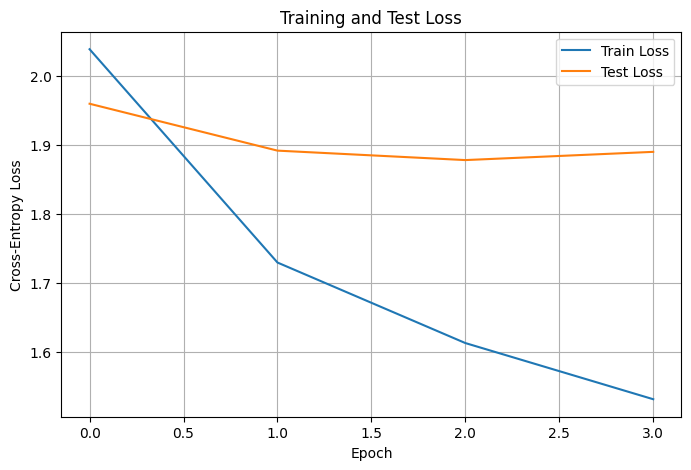

In [95]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.plot(train_loss_, label="Train Loss")
plt.plot(test_loss_, label="Test Loss")

plt.title("Training and Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Cross-Entropy Loss")

plt.legend()
plt.grid(True)

plt.show()

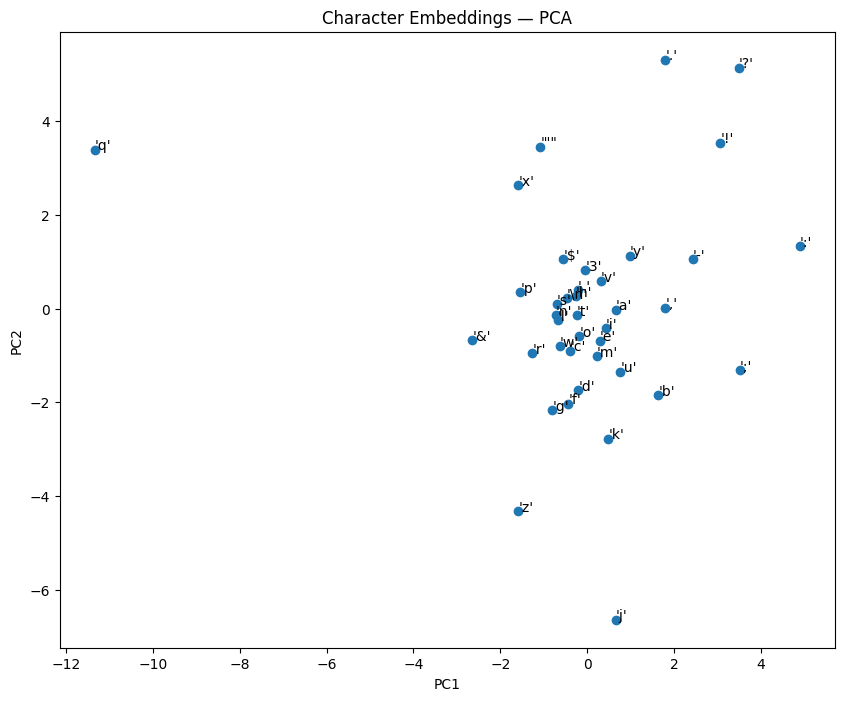

In [96]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# Get learned embeddings
embeddings = model[0].weight.detach().cpu().numpy()

# PCA → 2 dimensions
pca = PCA(n_components=2)
embeddings_2d = pca.fit_transform(embeddings)

# Plot
plt.figure(figsize=(10, 8))

plt.scatter(
    embeddings_2d[:, 0],
    embeddings_2d[:, 1]
)

for i, char in enumerate(chars):
    plt.annotate(
        repr(char),
        (embeddings_2d[i, 0], embeddings_2d[i, 1])
    )

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Character Embeddings — PCA")
plt.show()